Initial integral scale (κ=1) at position 42 of total 54
0.00%
0.44%
0.95%
1.64%
2.51%
3.45%
4.64%
6.03%
7.53%
8.85%
10.18%
11.50%
12.69%
13.88%
15.13%
16.37%
17.46%
18.55%
19.68%
20.81%
21.95%
22.93%
23.91%
24.89%
25.88%
26.87%
27.68%
28.48%
29.36%
30.12%
30.88%
31.61%
32.35%
33.09%
33.83%
34.57%
35.31%
36.13%
36.95%
37.78%
38.50%
39.22%
39.97%
40.70%
41.42%
42.17%
42.91%
43.64%
44.39%
45.21%
46.03%
46.85%
47.67%
48.49%
49.33%
50.18%
51.03%
51.87%
52.72%
53.57%
54.42%
55.27%
56.13%
56.99%
57.86%
58.72%
59.58%
60.46%
61.33%
62.21%
63.09%
63.96%
64.85%
65.74%
66.65%
67.56%
68.47%
69.38%
70.29%
71.23%
72.17%
73.12%
74.07%
75.02%
75.98%
76.93%
77.90%
78.09%
78.29%
78.62%
79.09%
79.68%
80.35%
81.11%
81.95%
82.80%
83.69%
84.61%
84.79%
84.97%
85.29%
85.74%
86.29%
86.93%
87.66%
88.47%
89.31%
90.17%
91.10%
92.03%
92.22%
92.42%
92.78%
93.27%
93.88%
94.63%
95.38%
96.02%
96.59%
97.17%
97.74%
98.41%
99.07%
99.79%
100.00%


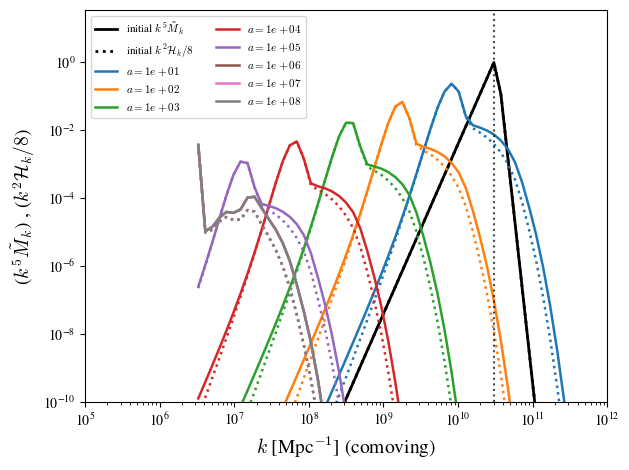

In [ ]:


import jax.numpy as np
from jax.scipy.integrate import trapezoid
import matplotlib.pyplot as plt
import matplotlib
import jax
import diffrax

matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

jax.config.update("jax_enable_x64", True)

# ----------------
# CONSTANTS/UNITS
# ----------------
lg10 = np.log(10.0)

eV  = 1.0
MeV = 1e6 * eV
GeV = 1e9 * eV
eV_to_Mpc = 1.564e29

NEWTON_G = 6.709e-57
T_CMB = 2.348e-4 * eV
T_EW = 100.0 * GeV
g_EW = 110.75
aEW = T_CMB / T_EW

H0 = np.sqrt(8.0 * np.pi**3 * NEWTON_G * g_EW / 90.0) * T_EW**2 * eV_to_Mpc * aEW
k0 = 2.0 * np.pi * H0


Nk = 54
Nth = 40

K_TILDE_LOG   = np.linspace(-4.0, 1.0, Nk)
K_TILDE_ARRAY = 10.0**(K_TILDE_LOG)          # κ values
K_ARRAY       = k0 * K_TILDE_ARRAY           # physical k (only for plotting)

X_ARRAY = np.linspace(-1.0, 1.0, Nth)

Q_GRID  = K_TILDE_ARRAY[:, None, None]       # (Nq,1,1)
K_GRID  = K_TILDE_ARRAY[None, :, None]       # (1,Nk,1)
X_GRID  = X_ARRAY[None, None, :]             # (1,1,Nth)
S2_GRID = 1.0 - X_GRID**2

# Measure for ∫ d log10 κ : dκ = ln10 * κ d log10 κ
# so ∫ dκ (...) = ∫ dlog10κ [ln10 * κ * (...)]
MEASURE_LOGK = lg10 * K_TILDE_ARRAY[None, :]  # shape (1, Nk)

# ----------------
# COSMO FUNCTIONS
# ----------------
def Hubble(a_aEW):
    return H0 / a_aEW**2

def Delta_t(a_aEW):
    return a_aEW / H0

def prefactor(a_aEW):
    return Delta_t(a_aEW) * (k0**2) * a_aEW / H0

# -------------

# -------------
def k1sqr_tilde(k_tilde, q_tilde, x):
    # κ1^2 = κ^2 + η^2 - 2 η κ x
    return k_tilde**2 + q_tilde**2 - 2.0 * q_tilde * k_tilde * x

def kappa1_from_kqx(K, Q, X):
    return np.sqrt(np.clip(k1sqr_tilde(K, Q, X), 0.0, None))

# -------------
# INTERPOLATOR
# -------------
def make_interp(values):
    # 1D linear interpolation on κ-grid, zero outside
    def interp_fn(x):
        return np.interp(x, K_TILDE_ARRAY, values, left=0.0, right=0.0)
    return interp_fn

# -------------------------------------------------
# m(κ)=k0^5 \tilde M(k0 κ), u(κ)=k0^5 \tilde U(k0 κ)
# -------------------------------------------------

def dmdln_a_curly(mf, uf, hf):
    """
    Curly braces for dm/d ln a in κ, evolving tildeM(κ).

    M,U: <X_α> = α^4 tildeX_α
    H:   <H_α> = α^2 barH_α  (hf returns barH)

    x = cosθ, so sin^3θ dθ -> (1-x^2) dx.
    """
    Q = Q_GRID
    K = K_GRID
    X = X_GRID
    S2 = S2_GRID

    K1 = kappa1_from_kqx(K, Q, X)

    # m(κ) on K-grid, u(κ1) on K1-grid
    m_k  = mf(K_TILDE_ARRAY).reshape(K.shape)                # (1,Nk,1)
    u_k1 = uf(K1.reshape(-1,)).reshape(K1.shape)             # (Nq,Nk,Nth)

    # transfer term
    integrand_x = 0.5 * K**4 * (Q**2 + K**2 - Q*K*X) * S2 * m_k * u_k1
    int_x       = trapezoid(integrand_x, X_ARRAY, axis=2)    # (Nq,Nk)
    first_term  = trapezoid(MEASURE_LOGK * int_x, K_TILDE_LOG, axis=1)  # (Nq,)

    # damping term: -(2/3) q^2 m(q) ∫ dκ κ^4 (2m+u)
    m_line = mf(K_TILDE_ARRAY)       # (Nk,)
    u_line = uf(K_TILDE_ARRAY)       # (Nk,)
    J_hat  = trapezoid(lg10 * K_TILDE_ARRAY**5 * (2.0*m_line + u_line), K_TILDE_LOG)
    analytic_term = -(2.0/3.0) * (K_TILDE_ARRAY**2) * m_line * J_hat

    # helicity source term for M with <H>=k^2 barH:
    # (1/q^4) * ∫ dk (1/3) (q^2 k^2/(4π)^2) H_q H_k
    # H_q=q^2 barH_q, H_k=k^2 barH_k  => (1/3)/(4π)^2 * barH_q ∫ dk k^4 barH_k
    h_line = hf(K_TILDE_ARRAY)  # barH(κ)
    I_h4   = trapezoid(lg10 * K_TILDE_ARRAY**5 * h_line, K_TILDE_LOG)  # ∫ dκ κ^4 h
    hel_term = (1.0/3.0) * h_line * I_h4 / ((4.0*np.pi)**2)

    return first_term + analytic_term + hel_term


def dudln_a_curly(mf, uf, hf):
    """
    Curly braces for du/d ln a in κ, evolving tildeU(κ).

    M,U: <X_α> = α^4 tildeX_α
    H:   <H_α> = α^2 barH_α  (hf returns barH)

    x = cosθ, so:
      sinθ dθ -> dx,
      sin^3θ dθ -> (1-x^2) dx.
    """
    Q = Q_GRID
    K = K_GRID
    X = X_GRID
    S2 = S2_GRID

    K1 = kappa1_from_kqx(K, Q, X)

    m_k  = mf(K_TILDE_ARRAY).reshape(K.shape)
    u_k  = uf(K_TILDE_ARRAY).reshape(K.shape)
    m_k1 = mf(K1.reshape(-1,)).reshape(K1.shape)
    u_k1 = uf(K1.reshape(-1,)).reshape(K1.shape)

    # barH on-grid + at κ1
    h_k  = hf(K_TILDE_ARRAY).reshape(K.shape)
    h_k1 = hf(K1.reshape(-1,)).reshape(K1.shape)

    invQ = np.where(Q > 0.0, 1.0 / Q, 0.0)


    k1sq = np.clip(k1sqr_tilde(K, Q, X), 0.0, None)

    
    d1 = (K**5 * 0.25) * invQ * (Q*K*S2 + 2.0*k1sq*X) * m_k * m_k1

   
    d2 = (K**5 * 0.25) * (3.0*K - Q*X) * S2 * u_k * u_k1

   
    d3 = (1.0 / ((16.0*np.pi)**2)) * invQ * (K**4) * (-2.0*Q - Q*S2 + 2.0*K*X) * h_k * h_k1

    integral_x = trapezoid(d1 + d2 + d3, X_ARRAY, axis=2)  # (Nq,Nk)
    first_term = trapezoid(MEASURE_LOGK * integral_x, K_TILDE_LOG, axis=1)  # (Nq,)

    # damping term: -(2/3) q^2 u(q) ∫ dκ κ^4 (m+u)
    m_line = mf(K_TILDE_ARRAY)
    u_line = uf(K_TILDE_ARRAY)
    J2_hat = trapezoid(lg10 * K_TILDE_ARRAY**5 * (m_line + u_line), K_TILDE_LOG)
    analytic_term = -(2.0/3.0) * (K_TILDE_ARRAY**2) * u_line * J2_hat

    return first_term + analytic_term



def dhdln_a_curly(mf, uf, hf):
    """
    Curly braces for d(barH)/d ln a in κ.

    M,U: <X_α> = α^4 tildeX_α
    H:   <H_α> = α^2 barH_α  (hf returns barH)

    Since H_q = q^2 barH_q, we divide the original H_q equation by q^2.
    x = cosθ, so sin^3θ dθ -> (1-x^2) dx.
    """
    Q = Q_GRID
    K = K_GRID
    X = X_GRID
    S2 = S2_GRID

    K1 = kappa1_from_kqx(K, Q, X)

    # angular term:
    # (1/q^2) * ∫ dk ∫ dθ [ q^4 k^2/(2k1^4) sin^3θ U_k1 H_k ]
    # U_k1 = k1^4 tildeU_k1 cancels k1^-4; H_k = k^2 barH_k
    # => (q^2/2) ∫ dk ∫ dx k^4 (1-x^2) tildeU(k1) barH(k)
    u_k1 = uf(K1.reshape(-1,)).reshape(K1.shape)             
    h_k  = hf(K_TILDE_ARRAY).reshape(K.shape)               

    integrand_x = 0.5 * (Q**2) * (K**4) * S2 * u_k1 * h_k
    int_x       = trapezoid(integrand_x, X_ARRAY, axis=2)    
    ang_term    = trapezoid(MEASURE_LOGK * int_x, K_TILDE_LOG, axis=1)  

    # non-angular terms:
    # (1/q^2)*∫dk[ (4k^2/3) M_q H_k - (4q^2/3) M_k H_q - (2q^2/3) U_k H_q ]
    # with M_q=q^4 tildeM_q, M_k=k^4 tildeM_k, U_k=k^4 tildeU_k,
    # H_k=k^2 barH_k, H_q=q^2 barH_q
    m_line = mf(K_TILDE_ARRAY)  # tildeM(κ)
    u_line = uf(K_TILDE_ARRAY)  # tildeU(κ)
    h_line = hf(K_TILDE_ARRAY)  # barH(κ)

    I_h4 = trapezoid(lg10 * K_TILDE_ARRAY**5 * h_line, K_TILDE_LOG)  # ∫ dκ κ^4 barH
    Jm4  = trapezoid(lg10 * K_TILDE_ARRAY**5 * m_line, K_TILDE_LOG)  # ∫ dκ κ^4 tildeM
    Ju4  = trapezoid(lg10 * K_TILDE_ARRAY**5 * u_line, K_TILDE_LOG)  # ∫ dκ κ^4 tildeU

    nonang_term = (4.0/3.0) * (K_TILDE_ARRAY**2) * m_line * I_h4 \
                  - (4.0/3.0) * (K_TILDE_ARRAY**2) * h_line * Jm4 \
                  - (2.0/3.0) * (K_TILDE_ARRAY**2) * h_line * Ju4

    return ang_term + nonang_term


def rhs(lna, F, args):
    a_aEW = np.exp(lna)

    m_now = F[:Nk]
    u_now = F[Nk:2*Nk]
    h_now = F[2*Nk:]

    mf = make_interp(m_now)
    uf = make_interp(u_now)
    hf = make_interp(h_now)

    factor = prefactor(a_aEW)
    dm = factor * dmdln_a_curly(mf, uf, hf)
    du = factor * dudln_a_curly(mf, uf, hf)
    dh = factor * dhdln_a_curly(mf, uf, hf)

    return np.concatenate((dm, du, dh))




# -------------------------
# SOLVE
# -------------------------
a_aEW_in  = np.log(1.0)

a_aEW_end = np.log(1e6)   
tsave = np.linspace(a_aEW_in, a_aEW_end, 100)

# initial peak at κ=1
kI_index = np.argmin(np.abs(K_TILDE_ARRAY - 1.0))
print(f"Initial integral scale (κ=1) at position {kI_index} of total {Nk}")

# ICs for m(κ), u(κ) (dimensionless):
m0 = np.where(np.arange(Nk) <= kI_index, 0.5, 0.5 * K_TILDE_ARRAY**(-25.0))
u0 = np.where(np.arange(Nk) <= kI_index, 0.5, 0.5 * K_TILDE_ARRAY**(-25.0))
h0 = 8.0*np.pi * K_TILDE_ARRAY * m0      # (optionally multiply by a helicity fraction f_hel <= 1)
F0 = np.concatenate((m0, u0, h0))


terms  = diffrax.ODETerm(rhs)
solver = diffrax.Kvaerno5()
saveat = diffrax.SaveAt(ts=tsave)
stepsize_controller = diffrax.PIDController(rtol=1e-4, atol=1e-6)

sol = diffrax.diffeqsolve(
    terms,
    solver,
    a_aEW_in,
    a_aEW_end,
    1e-3,
    F0,
    saveat=saveat,
    stepsize_controller=stepsize_controller,
    progress_meter=diffrax.TextProgressMeter(minimum_increase=0.001),
)

m_t = sol.ys[:, :Nk]        # tildeM(κ)
u_t = sol.ys[:, Nk:2*Nk]    # tildeU(κ)
h_t = sol.ys[:, 2*Nk:]      # H(κ)



# -------------------------
# PLOTTING
# magnetic: k^5 \tilde M_k  (solid)
# helical : k^2 H_k / 8     (dotted), with H_k = k^2 \bar H_k => k^2 H_k/8 = k^4 \bar H_k / 8
# -------------------------
a_targets   = np.array([1e1, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8])
lna_targets = np.log(a_targets)

fig, ax = plt.subplots()

# --- magnetic spectrum normalization
spec0_M = (K_TILDE_ARRAY**5) * m_t[0]
norm_M  = np.max(spec0_M)

# --- helical spectrum normalization
spec0_H = (K_TILDE_ARRAY**4) * np.abs(h_t[0]) / 8.0 * np.pi
norm_H  = np.max(spec0_H) + 1e-300

# initial curves
ax.loglog(K_ARRAY, spec0_M / norm_M, color="k", ls="-", lw=2, label=r"initial $k^5\tilde M_k$")
ax.loglog(K_ARRAY, spec0_H / norm_H, color="k", ls=":", lw=2, label=r"initial $k^2\mathcal{H}_k/8$")

for a_target, lna_target in zip(a_targets, lna_targets):
    idx = np.argmin(np.abs(tsave - lna_target))

    # solid magnetic curve
    spec_M = (K_TILDE_ARRAY**5) * m_t[idx]
    lineM, = ax.loglog(K_ARRAY, spec_M / norm_M, lw=1.8, ls="-", label=fr"$a={a_target:.0e}$")

    # dotted helical curve
    c = lineM.get_color()
    spec_H = (K_TILDE_ARRAY**4) * np.abs(h_t[idx]) / 8.0 * np.pi
    # (k0**4 cancels in your normalization; include it only if you ever compare absolute amplitudes)
    ax.loglog(K_ARRAY, spec_H / norm_H, lw=1.8, ls=":", color=c, label="_nolegend_")

# initial integral scale
kI_init = K_ARRAY[kI_index]
ax.axvline(kI_init, color="k", linestyle=":", alpha=0.7)

ax.set_xlabel("$k$ [Mpc$^{-1}$] (comoving)", fontsize=14)
ax.set_ylabel(r"($k^5\tilde M_k$) , ($k^2\mathcal{H}_k/8$) ", fontsize=14)
ax.set_ylim(1e-10)
ax.set_xlim(1e5, 1e12)
ax.legend(fontsize=8, ncol=2, loc="upper left", frameon=True)

plt.tight_layout()
plt.show()